# Recruitment Source Analysis and Data Visualization
**Objective:** Identify the best source of recruitment for a tech startup, based on previous data of candidate sources and recruitment strategies.

## Import Required Library

In [1]:
%%capture
pip install pandas plotnine

In [2]:
import pandas as pd
from plotnine import ggplot, aes, geom_col, labs, theme_minimal

## Load the Dataset

In [3]:
A = pd.read_csv("Recruitment_Data_updated.csv")

## Dataset Overview

In [4]:
A.head()

,attrition,performance_rating,sales_quota_pct,recruiting_source
0,0.000707,2.976686,0.604739,Applied Online
1,-0.019452,2.989157,0.396567,NaN
2,-0.009998,2.993355,0.206242,Applied Online
3,-0.003004,1.989966,-0.475037,NaN
4,-0.025405,3.016559,0.345470,Campus


In [5]:
A.shape

(107354, 4)

In [6]:
A.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107354 entries, 0 to 107353
Data columns (total 4 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   attrition           107354 non-null  float64
 1   performance_rating  107354 non-null  float64
 2   sales_quota_pct     107354 non-null  float64
 3   recruiting_source   57753 non-null   object 
dtypes: float64(3), object(1)
memory usage: 3.3+ MB


In [7]:
A.describe()

,attrition,performance_rating,sales_quota_pct
count,107354.000000,107354.000000,107354.000000
mean,0.213198,2.895066,1.082606
std,0.409639,0.682871,0.710279
min,-0.042386,0.964432,-0.739909
25%,-0.004684,2.022333,0.589342
50%,0.003484,2.998005,1.069800
75%,0.016809,3.010101,1.532299
max,1.038685,5.027383,3.701694


In [8]:
A.isnull().sum()

attrition                 0
performance_rating        0
sales_quota_pct           0
recruiting_source     49601
dtype: int64

## Identify Recruitment Source Groups

In [9]:
A["recruiting_source"].value_counts()

recruiting_source
Applied Online    30966
Campus            13453
Referral          10926
Search Firm        2408
Name: count, dtype: int64

## Average Sales Number by Recruiting Source

In [10]:
Average_Sales = A.groupby("recruiting_source")["sales_quota_pct"].mean()
Average_Sales

recruiting_source
Applied Online    1.080959
Campus            1.076408
Referral          1.075538
Search Firm       1.103426
Name: sales_quota_pct, dtype: float64

## Average Attrition Number by Recruiting Source

In [11]:
Average_Attrition = A.groupby("recruiting_source")["attrition"].mean()
Average_Attrition

recruiting_source
Applied Online    0.213370
Campus            0.215109
Referral          0.214920
Search Firm       0.208177
Name: attrition, dtype: float64

### Observation
**Search Firm** has the highest average sales performance *and* the lowest average attrition among the four sources.


# Data Visualization

## Attrition by Recruiting Source

In [12]:
Attrition_Data = Average_Attrition.reset_index()
Attrition_Data

,recruiting_source,attrition
0,Applied Online,0.213370
1,Campus,0.215109
2,Referral,0.214920
3,Search Firm,0.208177


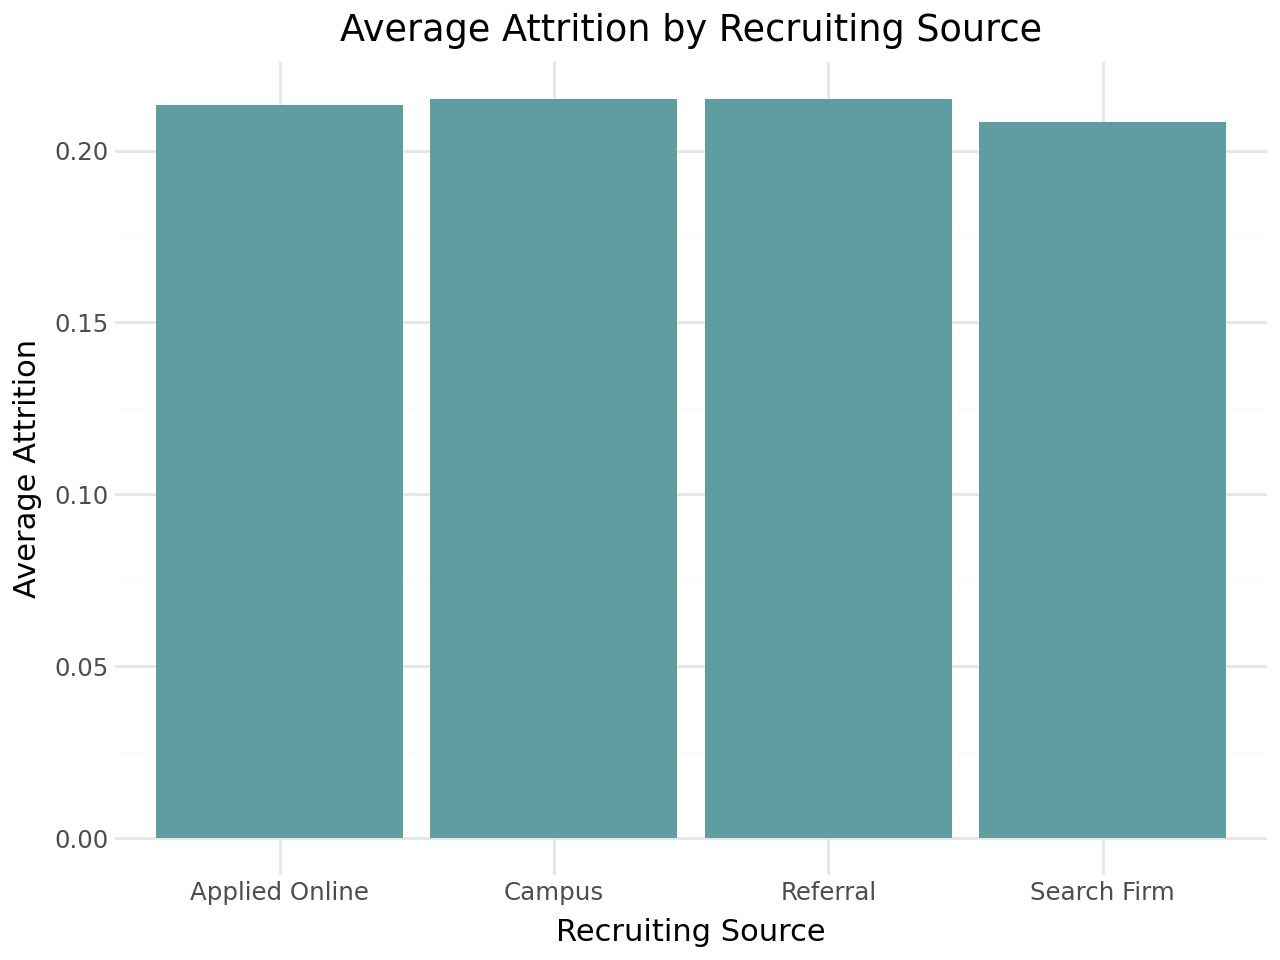

In [13]:
(ggplot(Attrition_Data, aes(x="recruiting_source", y="attrition"))
    + geom_col(fill="cadetblue")
    + labs(title="Average Attrition by Recruiting Source",
           x="Recruiting Source", y="Average Attrition") 
    + theme_minimal())

### Observation
Search Firm has the lowest average attrition among the four recruitment sources.

## Sales Performance by Recruiting Source

In [14]:
Sales_Data = Average_Sales.reset_index()
Sales_Data

,recruiting_source,sales_quota_pct
0,Applied Online,1.080959
1,Campus,1.076408
2,Referral,1.075538
3,Search Firm,1.103426


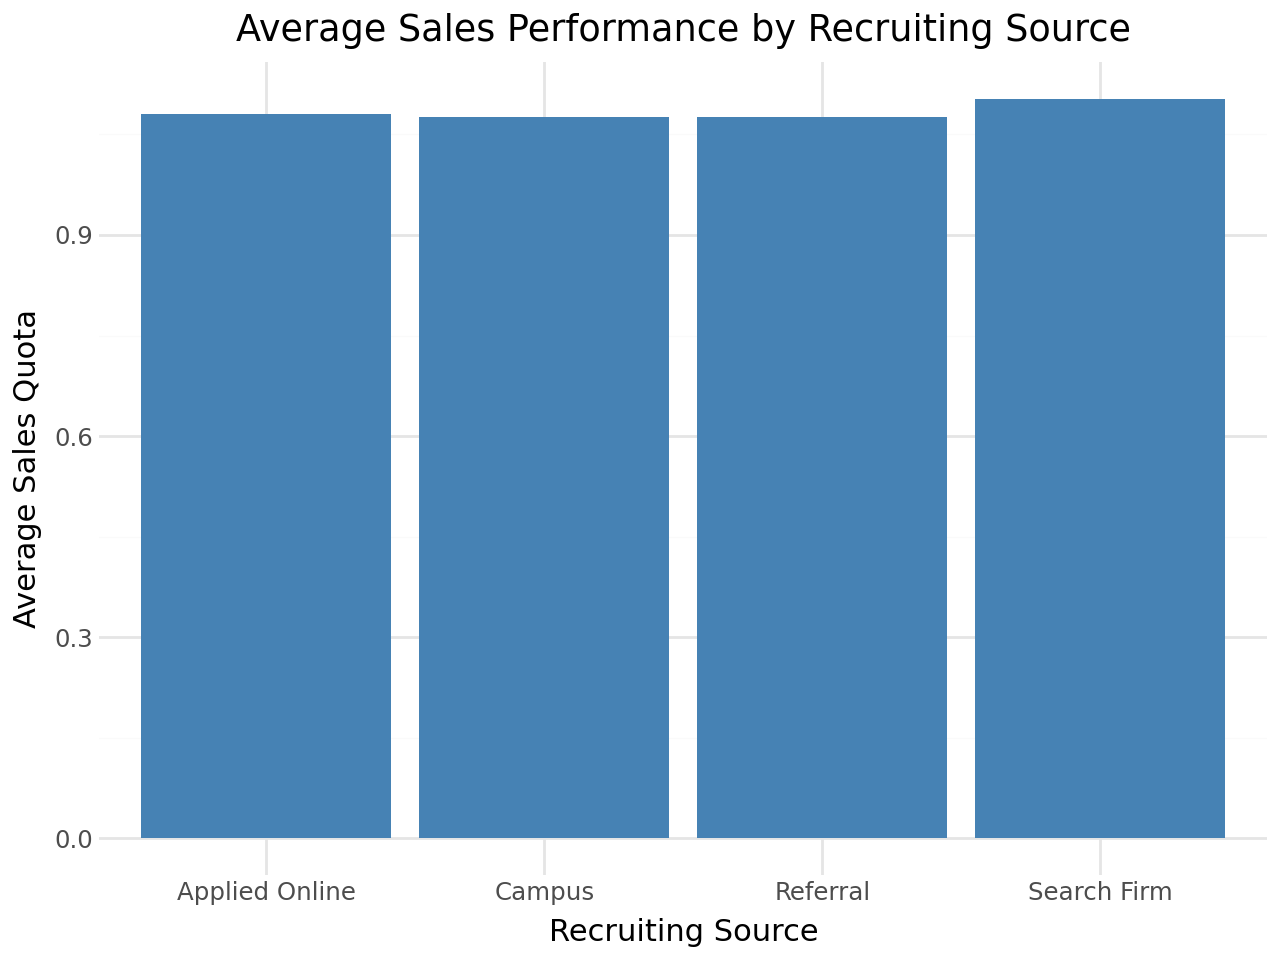

In [15]:
(ggplot(Sales_Data, aes(x="recruiting_source", y="sales_quota_pct"))
    + geom_col(fill="steelblue")
    + labs(title="Average Sales Performance by Recruiting Source",
           x="Recruiting Source",
           y="Average Sales Quota")
    + theme_minimal())

### Observation
Search Firm has the highest average sales performance among the four recruitment sources.

# Conclusion
Based on the visual comparison, Search Firm performs best among the four recruitment sources. It has the highest average sales performance and the lowest average attrition. Therefore, Search Firm can be considered the strongest recruitment source based on these two measures.